### Investigate extreme cases

##### 1. Reproduce example presented during the lecture (drug survey). 

In [20]:
import arviz as az
import pymc as pm  
import numpy as np

def generate_deterministic_model_samples(n_samples, yes_count):
    with pm.Model() as model:
        p_d = pm.Uniform("p_d", 0, 1)

        p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)

        answers = pm.Binomial("answers", n=n_samples, p=p_observed, observed=yes_count)

        idata = pm.sample(2000, tune=2500, return_inferencedata=True)

    az.plot_trace(idata, var_names=["p_d", "p_observed"], show=True)
    return idata

##### 2. See what happens when the number of “yes” answers (out of 100) is 
- 20 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.


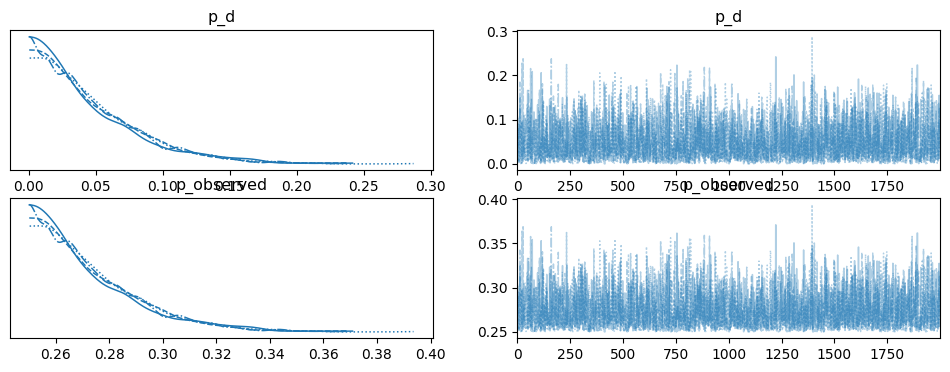

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [21]:
generate_deterministic_model_samples(100, 20)

- 10 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 9 seconds.


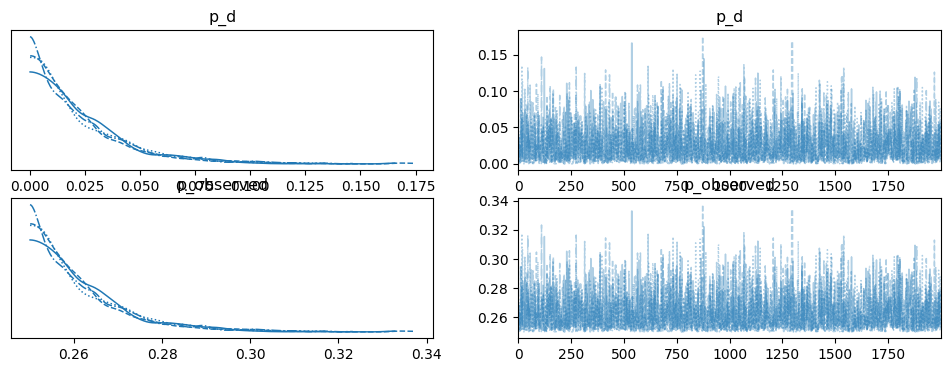

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [22]:
generate_deterministic_model_samples(100, 10)

- 5 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 9 seconds.


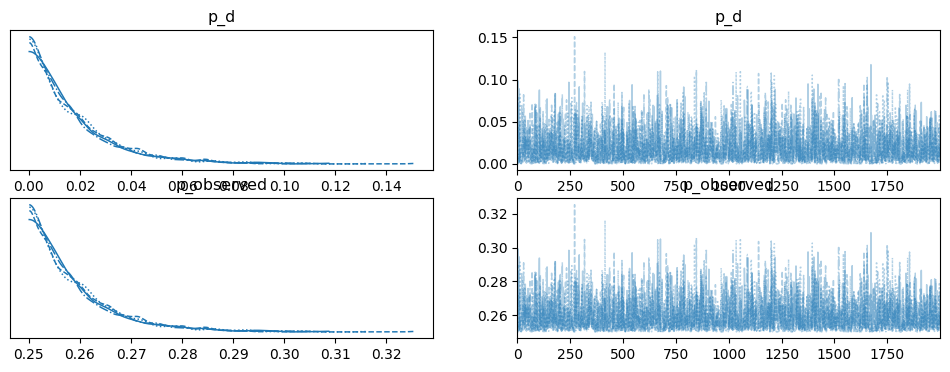

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [23]:
generate_deterministic_model_samples(100, 5)

Explain.

- Niezależnie od ilości odpowiedzi "TAK" wykresy osiągają swoje maksima p_observed w około 0.25, ponieważ wszystkie odpowiedzi są ponieżej 25 czyli wielkości 0.25 populacji 
- im mniej odpowiedzi "TAK", tym szybciej wykresy zbliżają się do osi X, co oznacza zwiększoną pewność estymacji
- im mniej odpowiedzi "TAK", tym bardziej skoncentrowany rozkład
- Im bardziej wynik ankiety odbiega od wartości losowej (0.25), tym model pewniej i precyzyjniej szacuje p_d. Wyniki bliskie 25 „TAK” na 100 odpowiedzi prowadzą do największej niepewności, bo nie wiadomo, czy wynika to z rzeczywistego zjawiska, czy z losowości wbudowanej w sposób zadawania pytań.

### Generate sample data

##### 1. Modify previous example in order to obtain a sample datasets:

In [24]:
def generate_deterministic_model_probability(n_samples, probability_yes):
    p_observed = 0.25 + 0.5 * probability_yes

    with pm.Model() as generative_model:
        answers_dist = pm.Binomial('answers', n=1, p=p_observed, shape=n_samples)
        prior_samples = pm.sample_prior_predictive(samples=1, random_seed=42)

    answers = prior_samples.prior['answers'].values[0, 0, :]
    yes_count = int(np.sum(answers))

    print(f"p_d = {probability_yes}:")
    print(f"  p_observed ze wzoru: {p_observed:.2f}")
    print(f"  Liczba odpowiedzi TAK: {yes_count}/{n_samples} ({yes_count/n_samples:.2f})")
    print(f"  Generowane odpowiedzi: {answers}")

- Generate a set of 100 answers for probability of a randomly chosen student taking drugs equal to: 0.1; 0.5; 0.9

In [25]:
generate_deterministic_model_probability(100, 0.1)

Sampling: [answers]


p_d = 0.1:
  p_observed ze wzoru: 0.30
  Liczba odpowiedzi TAK: 29/100 (0.29)
  Generowane odpowiedzi: [1 1 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0
 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [26]:
generate_deterministic_model_probability(100, 0.5)

Sampling: [answers]


p_d = 0.5:
  p_observed ze wzoru: 0.50
  Liczba odpowiedzi TAK: 54/100 (0.54)
  Generowane odpowiedzi: [1 1 1 0 1 0 1 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0
 1 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0 0 0
 1 1 0 1 1 1 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0]


In [27]:
generate_deterministic_model_probability(100, 0.9)

Sampling: [answers]


p_d = 0.9:
  p_observed ze wzoru: 0.70
  Liczba odpowiedzi TAK: 71/100 (0.71)
  Generowane odpowiedzi: [0 0 0 1 0 1 0 0 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 1 1 1 0 1 1
 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


- Set the probability of a randomly chosen student taking drugs at 0.1, count of the group at 100. The survey was repeated 50 times, generate number of “yes” answers for each attempt.

Sampling: [yes_counts]


p_d = 0.1 | p_observed = 0.30
Wyniki 50 prób: [36, 36, 35, 28, 38, 26, 43, 33, 25, 29, 31, 26, 27, 37, 29, 24, 37, 20, 33, 30, 25, 29, 34, 35, 23, 31, 25, 31, 33, 33, 28, 31, 24, 31, 33, 32, 21, 36, 32, 23, 26, 35, 31, 25, 33, 34, 28, 22, 24, 30]
Średnia: 30.02
Odchylenie standardowe: 4.97
Mediana: 31
Min: 20 | Max: 43


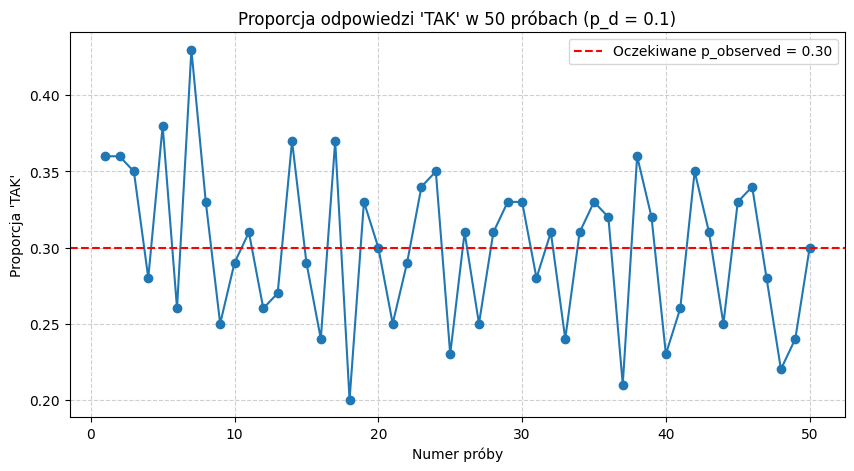

In [28]:
import matplotlib.pyplot as plt

p_drugs = 0.1
n_students = 100
n_attempts = 50


def generate_multiple_surveys(n_samples, probability, n_attempts):
    p_observed = 0.25 + 0.5 * probability

    with pm.Model() as repeated_survey_model:
        yes_counts_dist = pm.Binomial('yes_counts', n=n_samples, p=p_observed, shape=n_attempts)
        prior_samples = pm.sample_prior_predictive(samples=1, random_seed=42)

    yes_counts = prior_samples.prior['yes_counts'].values[0, 0, :]
    yes_counts_array = np.array(yes_counts)

    print(f"p_d = {probability} | p_observed = {p_observed:.2f}")
    print(f"Wyniki 50 prób: {yes_counts_array.astype(int).tolist()}")
    print(f"Średnia: {np.mean(yes_counts_array):.2f}")
    print(f"Odchylenie standardowe: {np.std(yes_counts_array):.2f}")
    print(f"Mediana: {np.median(yes_counts_array):.0f}")
    print(f"Min: {np.min(yes_counts_array)} | Max: {np.max(yes_counts_array)}")

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, n_attempts + 1), yes_counts_array / n_samples, marker='o')
    plt.axhline(y=p_observed, color='r', linestyle='--', label=f"Oczekiwane p_observed = {p_observed:.2f}")
    plt.title(f"Proporcja odpowiedzi 'TAK' w {n_attempts} próbach (p_d = {probability})")
    plt.xlabel("Numer próby")
    plt.ylabel("Proporcja 'TAK'")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


generate_multiple_surveys(100, 0.1, 50)

**Wnioski**

- im bliżej skrajnych wartości tym model jest pewniejszy że czegoś najprawdopodobniej wcale nie ma (dla p=0.1 p_d jest największe w 0) lub jest pewny że jest (dla 0.9 p_d jest największe w 1) 
- dla 0.5 p_d jest bardzo rozłożont i zawiera wartości od 0 do 1
- Rozrzut wyników pokazuje, że pojedyncze badanie może wprowadzać duży błąd
- Wspólna analiza wielu prób zmniejsza wariancję estymacji p_d -> im więcej badań, tym pewniejsze wnioski o p_d